In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pmdarima import auto_arima
import pickle
import joblib

In [178]:
df = pd.read_parquet("filtered_interpolated.parquet")

In [179]:
df

,Comodity,Provinsi,Price,Close MYRUSD,High MYRUSD,Low MYRUSD,Open MYRUSD,Close SGDUSD,High SGDUSD,Low SGDUSD,...,cos_month,sin_day,cos_day,sin_dayofweek,cos_dayofweek,sin_weekofyear,cos_weekofyear,sin_quarter,cos_quarter,is_holiday
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,0,0,28970.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.660254e-01,0.201299,0.979530,-0.974928,-0.222521,0.0,1.0,1.0,6.123234e-17,1
2022-01-02,0,0,29900.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.660254e-01,0.394356,0.918958,-0.781831,0.623490,0.0,1.0,1.0,6.123234e-17,0
2022-01-03,0,0,28970.0,0.239521,0.240038,0.239722,0.240038,0.741730,0.742115,0.738531,...,8.660254e-01,0.571268,0.820763,0.000000,1.000000,0.120537,0.992709,1.0,6.123234e-17,0
2022-01-04,0,0,29600.0,0.239808,0.239751,0.239006,0.239406,0.739033,0.739481,0.736269,...,8.660254e-01,0.724793,0.688967,0.781831,0.623490,0.120537,0.992709,1.0,6.123234e-17,0
2022-01-05,0,0,29540.0,0.239006,0.238949,0.238521,0.238949,0.737621,0.738880,0.737148,...,8.660254e-01,0.848644,0.528964,0.974928,-0.222521,0.120537,0.992709,1.0,6.123234e-17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-26,12,33,10710.0,0.242219,0.242872,0.241051,0.242219,0.775326,0.779910,0.775308,...,-1.836970e-16,-0.848644,0.528964,0.433884,-0.900969,-1.0,-0.0,-1.0,-1.836970e-16,0
2024-09-27,12,33,10570.0,0.241546,0.242984,0.241692,0.241546,0.778889,0.781983,0.777472,...,-1.836970e-16,-0.724793,0.688967,-0.433884,-0.900969,-1.0,-0.0,-1.0,-1.836970e-16,0
2024-09-28,12,33,10670.0,0.241956,0.243409,0.241936,0.241956,0.779534,0.781902,0.778009,...,-1.836970e-16,-0.571268,0.820763,-0.974928,-0.222521,-1.0,-0.0,-1.0,-1.836970e-16,0


In [180]:
features = list(df.columns)
features.pop(2)

'Price'

In [181]:
print(features)

['Comodity', 'Provinsi', 'Close MYRUSD', 'High MYRUSD', 'Low MYRUSD', 'Open MYRUSD', 'Close SGDUSD', 'High SGDUSD', 'Low SGDUSD', 'Open SGDUSD', 'Close THBUSD', 'High THBUSD', 'Low THBUSD', 'Open THBUSD', 'Close USDIDR', 'High USDIDR', 'Low USDIDR', 'Open USDIDR', 'Price Crude Oil WTI Futures Historical Data', 'Open Crude Oil WTI Futures Historical Data', 'High Crude Oil WTI Futures Historical Data', 'Low Crude Oil WTI Futures Historical Data', 'Vol. Crude Oil WTI Futures Historical Data', 'Change % Crude Oil WTI Futures Historical Data', 'Price Natural Gas Futures Historical Data', 'Open Natural Gas Futures Historical Data', 'High Natural Gas Futures Historical Data', 'Low Natural Gas Futures Historical Data', 'Vol. Natural Gas Futures Historical Data', 'Change % Natural Gas Futures Historical Data', 'Price Newcastle Coal Futures Historical Data', 'Open Newcastle Coal Futures Historical Data', 'High Newcastle Coal Futures Historical Data', 'Low Newcastle Coal Futures Historical Data',

In [173]:
prov = ['Aceh', 'Bali', 'Banten', 'Bengkulu', 'DI Yogyakarta',
       'DKI Jakarta', 'Gorontalo', 'Jambi', 'Jawa Barat', 'Jawa Tengah',
       'Jawa Timur', 'Kalimantan Barat', 'Kalimantan Selatan',
       'Kalimantan Tengah', 'Kalimantan Timur', 'Kalimantan Utara',
       'Kepulauan Bangka Belitung', 'Kepulauan Riau', 'Lampung', 'Maluku',
       'Maluku Utara', 'Nusa Tenggara Barat', 'Nusa Tenggara Timur',
       'Papua', 'Papua Barat', 'Riau', 'Sulawesi Barat',
       'Sulawesi Selatan', 'Sulawesi Tengah', 'Sulawesi Tenggara',
       'Sulawesi Utara', 'Sumatera Barat', 'Sumatera Selatan',
       'Sumatera Utara']
com = ['Bawang Merah', 'Bawang Putih Bonggol', 'Beras Medium',
       'Beras Premium', 'Cabai Merah Keriting', 'Cabai Rawit Merah',
       'Daging Ayam Ras', 'Daging Sapi Murni', 'Gula Konsumsi',
       'Minyak Goreng Curah', 'Minyak Goreng Kemasan Sederhana',
       'Telur Ayam Ras', 'Tepung Terigu (Curah)']

In [ ]:
for i in df['Comodity'].unique()[0:1]:
    for j in df['Provinsi'].unique()[0:1]:
        curr_state = (com[i], prov[j])
        df1 = df[(df['Comodity'] == i) & (df['Provinsi'] == j)]
        model = auto_arima(df1['Price'], m=12, seasonal=True,
                                D=3, trace=True,
                               error_action='ignore',  
                               suppress_warnings=True, 
                               stepwise=True, verbose=True, exogenous=df1[features])
        model.fit(df1['Price'], exogenous=df1[features])
        # joblib.dump(model, f"models/{i}_{j}.pkl", compress=3)
        forecast = model.predict(n_periods=92, exogenous=df1[features])
        forecast
        res = pd.DataFrame(forecast, index=pd.date_range(start='2024-10-01', periods=92, freq='D'), columns=['price'])
        res['Provinsi'] = prov[j]
        res['Comodity'] = com[i]
        res['id'] = res['Comodity'] + "/" + res['Provinsi'] + "/" + res.index.astype(str)
        res.pop('Provinsi')
        res.pop('Comodity')
        res = res[['id', 'price']]
        res.to_csv(f"output/{com[i]}_{prov[j]}.csv", index=False)

In [246]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Assuming 'features' is a list of exogenous variables
features = features  # Replace with actual feature names

# Iterate over unique commodities and provinces
for i in df["Comodity"].unique()[0:1]:
    for j in df["Provinsi"].unique()[0:1]:
        curr_state = (i, j)
        df1 = df[(df["Comodity"] == i) & (df["Provinsi"] == j)].copy()
        # Ensure datetime index
        df1 = df1.asfreq("D")
        p, d, q = 1, 1, 3  # Example order (tune accordingly)
        P, D, Q, m = 1, 2, 1, 12  # Seasonal order for monthly seasonality
        
        # Fit ARIMA with exogenous variables
        model = SARIMAX(df1["Price"],
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, m),
                        exog=df1['sin_day'],
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=False)

        # Forecast for 92 days
        forecast_index = pd.date_range(start="2024-10-01", periods=92, freq="D")
        forecast = results.get_forecast(steps=92, exog=df1['sin_day'].iloc[-92:])
        # forecast = results.get_forecast(steps=92)
        forecast_values = forecast.predicted_mean
        print(forecast_index)
        print(forecast_values)
        

        # Store results in DataFrame
        res = pd.DataFrame(forecast_values.values, columns=["price"], index=forecast_index)
        print(res)
        res["Provinsi"] = j
        res["Comodity"] = i
        # res["id"] = res["Comodity"] + "/" + res["Provinsi"] + "/" + res.index.astype(str)
        # res["id"] = res["Comodity"].astype(str) + "/" + res["Provinsi"].astype(str) + "/" + res.index.astype(str)

        # Drop unnecessary columns and save output
        res = res[["price"]]
        res.to_csv(f"output/{com[i]}_{prov[j]}.csv", index=True)

        print(f"Saved forecast for {i} in {j}")


c:\Users\moric\miniconda3\envs\ds-1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


DatetimeIndex(['2024-10-01', '2024-10-02', '2024-10-03', '2024-10-04',
               '2024-10-05', '2024-10-06', '2024-10-07', '2024-10-08',
               '2024-10-09', '2024-10-10', '2024-10-11', '2024-10-12',
               '2024-10-13', '2024-10-14', '2024-10-15', '2024-10-16',
               '2024-10-17', '2024-10-18', '2024-10-19', '2024-10-20',
               '2024-10-21', '2024-10-22', '2024-10-23', '2024-10-24',
               '2024-10-25', '2024-10-26', '2024-10-27', '2024-10-28',
               '2024-10-29', '2024-10-30', '2024-10-31', '2024-11-01',
               '2024-11-02', '2024-11-03', '2024-11-04', '2024-11-05',
               '2024-11-06', '2024-11-07', '2024-11-08', '2024-11-09',
               '2024-11-10', '2024-11-11', '2024-11-12', '2024-11-13',
               '2024-11-14', '2024-11-15', '2024-11-16', '2024-11-17',
               '2024-11-18', '2024-11-19', '2024-11-20', '2024-11-21',
               '2024-11-22', '2024-11-23', '2024-11-24', '2024-11-25',
      

In [247]:
res = pd.read_csv("output/Bawang Merah_Aceh.csv")

In [248]:
# res.set_index('Unnamed: 0')
res[["Date", "Price"]] = res[["Unnamed: 0", "price"]]
res = res.drop(["Unnamed: 0", "price"], axis=1)
res['Date'] = pd.to_datetime(res['Date'])

In [249]:
res = res.set_index("Date")

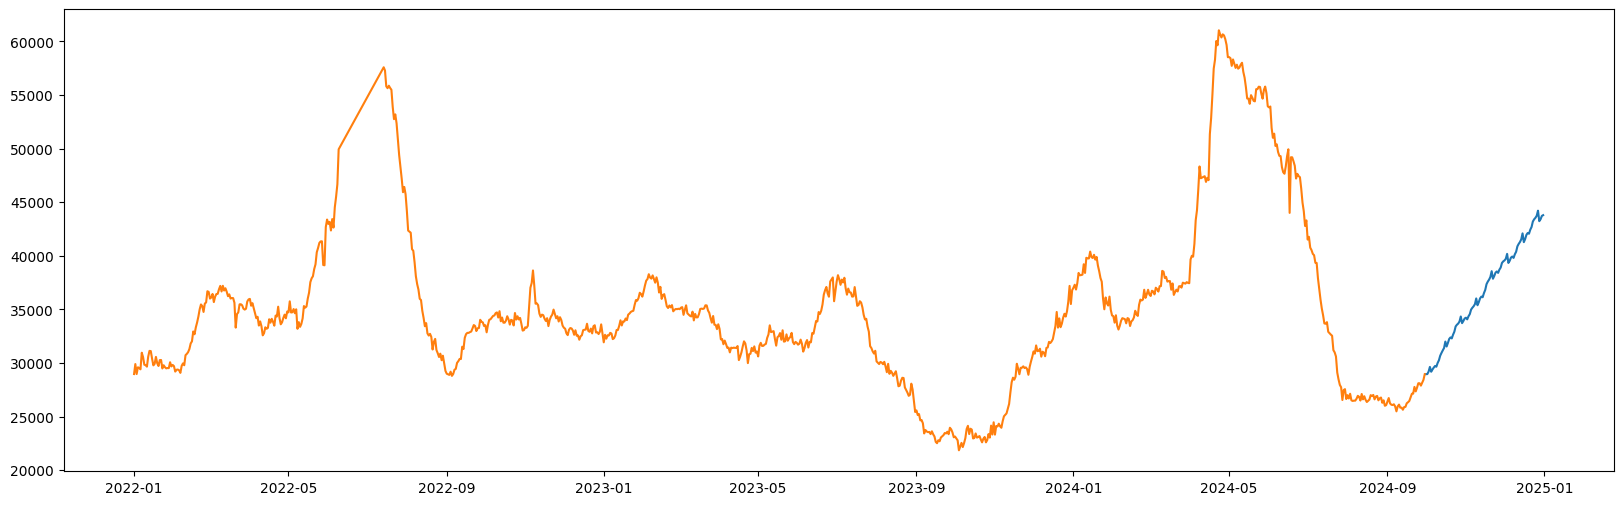

In [250]:
plt.figure(figsize=(20, 6))
plt.plot(res["Price"])
plt.plot(df[(df['Comodity'] == 0) & (df['Provinsi'] == 0)]['Price'])
plt.show()